In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import folium
from folium.plugins import FloatImage
import branca.colormap as cm
from pyproj import Transformer

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [2]:
## Parse 
def parse_cg5(filepath):
    records = []
    with open(filepath, 'r', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if line.startswith('/') or not line:
                continue
            parts = line.split()
            if len(parts) >= 15:
                try:
                    records.append({
                        'STATION' : float(parts[1]),
                        'ALT'     : float(parts[2]),
                        'GRAV'    : float(parts[3]),
                        'SD'      : float(parts[4]),
                        'TILTX'   : float(parts[5]),
                        'TILTY'   : float(parts[6]),
                        'TIDE'    : float(parts[8]),
                        'TIME'    : parts[11],
                        'DATE'    : parts[14],
                    })
                except (ValueError, IndexError):
                    pass
    df = pd.DataFrame(records)
    df['DATETIME'] = pd.to_datetime(df['DATE'] + ' ' + df['TIME'], format='%Y/%m/%d %H:%M:%S')
    return df

In [3]:
## File Loading 
DATA_DIR = Path('.')

raw = {
    'G2_CG1': parse_cg5('/Users/aucklynnsacco/work/classes/gpgn_486/griddy/GPGN486-Griddy-Project/data/Gravity_Group2_20220524/Group2_GravityData_cg5_1_20220524.TXT'),
    'G2_CG2': parse_cg5('/Users/aucklynnsacco/work/classes/gpgn_486/griddy/GPGN486-Griddy-Project/data/Gravity_Group2_20220524/Group2_GravityData_CG5_2_20220524.TXT'),
    'G3_CG1': parse_cg5('/Users/aucklynnsacco/work/classes/gpgn_486/griddy/GPGN486-Griddy-Project/data/Gravity_Group3_20220525/GROUP3_GRAVITY_CG5-1_05252022.TXT'),
    'G3_CG2': parse_cg5('/Users/aucklynnsacco/work/classes/gpgn_486/griddy/GPGN486-Griddy-Project/data/Gravity_Group3_20220525/GROUP3_GRAVITY_CG5-2_0252022.TXT'),
}

# G3_CG1 contains two sessions — split by date
g3_all = raw['G3_CG1']
raw['G2_CG1'] = g3_all[g3_all['DATE'] == '2022/05/24'].copy()
raw['G3_CG1'] = g3_all[g3_all['DATE'] == '2022/05/25'].copy()

for key, df in raw.items():
    t0 = df['DATETIME'].min()
    df['ELAPSED_HR'] = (df['DATETIME'] - t0).dt.total_seconds() / 3600
    print(f'{key}: {len(df)} readings, stations={sorted(df["STATION"].unique().tolist())}')

G2_CG1: 27 readings, stations=[3.0, 5.0, 7.0, 9.0, 11.0, 13.0, 15.0, 1000.0, 1001.0]
G2_CG2: 25 readings, stations=[2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 2000.0, 2001.0]
G3_CG1: 36 readings, stations=[1.0, 14.0, 17.0, 19.0, 21.0, 23.0, 25.0, 27.0, 29.0, 31.0, 3000.0, 3001.0]
G3_CG2: 61 readings, stations=[2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 18.0, 20.0, 22.0, 24.0, 26.0, 28.0, 30.0, 32.0, 2000.0, 2001.0, 4000.0, 4001.0]


In [4]:
## Average repeat readings
def average_stations(df):
    return df.groupby('STATION').agg(
        GRAV       = ('GRAV', 'mean'),
        SD         = ('SD', 'mean'),
        ALT        = ('ALT', 'mean'),
        TIDE       = ('TIDE', 'mean'),
        ELAPSED_HR = ('ELAPSED_HR', 'mean'),
        N          = ('GRAV', 'count'),
    ).reset_index()

avgs = {key: average_stations(df) for key, df in raw.items()}

for key, df in avgs.items():
    print(f'\n{key}:')
    print(df[['STATION','GRAV','SD','N']].to_string(index=False))


G2_CG1:
 STATION        GRAV       SD  N
     3.0 3407.360333 0.028333  3
     5.0 3405.617000 0.096000  3
     7.0 3403.761667 0.189000  3
     9.0 3402.738333 0.156333  3
    11.0 3402.320000 0.081667  3
    13.0 3401.393333 0.453333  3
    15.0 3400.992333 0.300667  3
  1000.0 3401.102333 0.015000  3
  1001.0 3401.247333 0.100000  3

G2_CG2:
 STATION        GRAV       SD  N
     2.0 3425.708333 0.026333  3
     4.0 3424.776000 0.121667  3
     6.0 3422.532333 0.099333  3
     8.0 3421.178200 0.081800  5
    10.0 3420.523333 0.042667  3
    12.0 3419.720500 0.325000  2
  2000.0 3419.119667 0.026333  3
  2001.0 3419.184667 0.060000  3

G3_CG1:
 STATION        GRAV       SD  N
     1.0 3409.556333 0.131333  3
    14.0 3401.653667 0.103000  3
    17.0 3401.746667 0.089000  3
    19.0 3401.556333 0.237333  3
    21.0 3402.411000 0.074000  3
    23.0 3401.665667 0.037333  3
    25.0 3400.937333 0.092333  3
    27.0 3399.965333 0.063000  3
    29.0 3399.502667 0.029333  3
    31.0 3398.27

In [5]:
## Drift corrections 
BASE_IDS = {
    'G2_CG1': (1000, 1001),
    'G2_CG2': (2000, 2001),
    'G3_CG1': (3000, 3001),
    'G3_CG2': (4000, 4001),
}

def drift_correct(df, base_start_id, base_end_id):
    df = df.copy()
    b0 = df[df['STATION'] == base_start_id].iloc[0]
    b1 = df[df['STATION'] == base_end_id].iloc[0]
    drift_rate = (b1['GRAV'] - b0['GRAV']) / (b1['ELAPSED_HR'] - b0['ELAPSED_HR'])
    df['DRIFT_CORR'] = df['GRAV'] - drift_rate * (df['ELAPSED_HR'] - b0['ELAPSED_HR'])
    base_corr = df[df['STATION'] == base_start_id]['DRIFT_CORR'].values[0]
    df['GRAV_DC'] = df['DRIFT_CORR'] - base_corr + b0['GRAV']
    df['DRIFT_RATE'] = drift_rate
    return df, drift_rate

corrected = {}
drift_rates = {}
for key, df in avgs.items():
    bs, be = BASE_IDS[key]
    corr_df, rate = drift_correct(df, bs, be)
    corrected[key] = corr_df
    drift_rates[key] = rate
    print(f'{key}: drift = {rate*24:.4f} mGal/day')

G2_CG1: drift = 1.2040 mGal/day
G2_CG2: drift = 0.5731 mGal/day
G3_CG1: drift = 0.6992 mGal/day
G3_CG2: drift = 0.8496 mGal/day


In [6]:
## Tide corrections: 
for key in corrected:
    corrected[key]['GRAV_TC'] = corrected[key]['GRAV_DC'] + corrected[key]['TIDE']

In [42]:
## Elevation: 
BASE_ALL = {1000,1001,2000,2001,3000,3001,4000,4001}

frames = []
for key, df in corrected.items():
    sub = df[~df['STATION'].isin(BASE_ALL)].copy()
    sub['SOURCE'] = key
    frames.append(sub)

merged = pd.concat(frames, ignore_index=True)

tie_stas = merged.groupby('STATION').size()
tie_stas = tie_stas[tie_stas > 1].index.tolist()
print(f'Tie stations: {tie_stas}')

combined = merged.groupby('STATION').agg(
    GRAV_TC    = ('GRAV_TC', 'mean'),
    ALT        = ('ALT', 'mean'),
    SD         = ('SD', 'mean'),
    ELAPSED_HR = ('ELAPSED_HR', 'mean'),
).reset_index().sort_values('STATION').reset_index(drop=True)

combined = combined.sort_values('STATION').reset_index(drop=True)
combined = combined.sort_values('STATION').reset_index(drop=True)
combined['DIST_M'] = combined.index * 200
combined['EASTING']  = 345054.92 + combined['DIST_M']
combined['NORTHING'] = 4473630.52

# Interpolate missing elevations (CG-5 #1 left ALT=0)
combined['ELEV_M'] = combined['ALT'].replace(0.0, np.nan)
combined['ELEV_M'] = combined['ELEV_M'].interpolate(method='linear').bfill()

print(combined[['STATION','DIST_M','ELEV_M','GRAV_TC','SD']].to_string(index=False))

Tie stations: [2.0, 4.0, 6.0, 8.0, 10.0, 12.0]
 STATION  DIST_M    ELEV_M     GRAV_TC       SD
     1.0       0  7.680600 3426.789217 0.131333
     2.0     200  7.680600 3425.920244 0.026333
     3.0     400  7.680600 3425.281834 0.028333
     4.0     600  7.680600 3424.975364 0.121667
     5.0     800  7.680600 3423.523935 0.096000
     6.0    1000  7.680600 3422.723914 0.099333
     7.0    1200  7.680600 3421.649803 0.189000
     8.0    1400  7.680600 3421.355762 0.081800
     9.0    1600  7.680600 3420.611306 0.156333
    10.0    1800  7.680600 3420.689794 0.042667
    11.0    2000  7.680600 3420.176469 0.081667
    12.0    2200  7.680600 3419.732855 0.234500
    13.0    2400 12.160950 3419.237936 0.453333
    14.0    2600 16.641300 3419.066228 0.103000
    15.0    2800 21.121650 3418.824596 0.300667
    16.0    3000 25.602000 3419.028431 0.025667
    17.0    3200 26.212350 3419.143283 0.089000
    18.0    3400 26.822700 3419.073204 0.081667
    19.0    3600 26.659950 3418.944917 0.

In [43]:
## Gravity Corrections: 
RHO     = 2.67       # g/cm³
LAT_DEG = 43.9       # update if survey is not in Ontario
LAT_RAD = np.radians(LAT_DEG)

sin2    = np.sin(LAT_RAD)**2
gamma_0 = 978032.67714 * (1 + 0.00193185138639 * sin2) / \
          np.sqrt(1 - 0.00669437999014 * sin2) / 1000
print(f'Theoretical gravity at {LAT_DEG}N: {gamma_0:.4f} mGal')

h = combined['ELEV_M'].values
combined['FAC'] = 0.3086 * h
combined['BC']  = -0.04193 * RHO * h
combined['FAA'] = combined['GRAV_TC'] + combined['FAC'] - gamma_0
combined['SBA'] = combined['FAA'] + combined['BC']

print(combined[['STATION','ELEV_M','FAC','BC','FAA','SBA']].round(3).to_string(index=False))

Theoretical gravity at 43.9N: 980.5204 mGal
 STATION  ELEV_M   FAC     BC      FAA      SBA
     1.0   7.681 2.370 -0.860 2448.639 2447.779
     2.0   7.681 2.370 -0.860 2447.770 2446.910
     3.0   7.681 2.370 -0.860 2447.132 2446.272
     4.0   7.681 2.370 -0.860 2446.825 2445.965
     5.0   7.681 2.370 -0.860 2445.374 2444.514
     6.0   7.681 2.370 -0.860 2444.574 2443.714
     7.0   7.681 2.370 -0.860 2443.500 2442.640
     8.0   7.681 2.370 -0.860 2443.206 2442.346
     9.0   7.681 2.370 -0.860 2442.461 2441.601
    10.0   7.681 2.370 -0.860 2442.540 2441.680
    11.0   7.681 2.370 -0.860 2442.026 2441.166
    12.0   7.681 2.370 -0.860 2441.583 2440.723
    13.0  12.161 3.753 -1.361 2442.470 2441.109
    14.0  16.641 5.136 -1.863 2443.681 2441.818
    15.0  21.122 6.518 -2.365 2444.822 2442.458
    16.0  25.602 7.901 -2.866 2446.409 2443.543
    17.0  26.212 8.089 -2.935 2446.712 2443.777
    18.0  26.823 8.277 -3.003 2446.830 2443.827
    19.0  26.660 8.227 -2.985 2446.652 2443.

In [44]:
BASE_ALL = {1000,1001,2000,2001,3000,3001,4000,4001}

# Reference all sessions to the SAME base station gravity value
# Use G2_CG1 base (station 1000) as the master reference
master_base = corrected['G2_CG1'][corrected['G2_CG1']['STATION']==1000]['GRAV_TC'].values[0]

for key in corrected:
    bs = BASE_IDS[key][0]
    session_base = corrected[key][corrected[key]['STATION']==bs]['GRAV_TC'].values[0]
    shift = master_base - session_base
    corrected[key]['GRAV_TC'] += shift
    print(f'{key}: shifted by {shift:.4f} mGal to match master base')

# Combine
merged = pd.concat([df[~df['STATION'].isin(BASE_ALL)].assign(SOURCE=key)
                    for key, df in corrected.items()], ignore_index=True)

combined = merged.groupby('STATION').agg(
    GRAV_TC=('GRAV_TC','mean'), ALT=('ALT','mean'),
    SD=('SD','mean'), ELAPSED_HR=('ELAPSED_HR','mean')
).reset_index().sort_values('STATION').reset_index(drop=True)

combined['DIST_M']   = (combined['STATION'] - 1) * 200
combined['EASTING']  = 345054.92 + combined['DIST_M']
combined['NORTHING'] = 4473630.52
combined['ELEV_M']   = combined['ALT'].replace(0.0, np.nan).interpolate().bfill()

RHO     = 2.67
LAT_RAD = np.radians(43.9)
sin2    = np.sin(LAT_RAD)**2
gamma_0 = 978032.67714*(1 + 0.00193185138639*sin2)/np.sqrt(1 - 0.00669437999014*sin2)/1000

h = combined['ELEV_M'].values
combined['FAC'] = 0.3086 * h
combined['BC']  = -0.04193 * RHO * h
combined['FAA'] = combined['GRAV_TC'] + combined['FAC'] - gamma_0
combined['SBA'] = combined['FAA'] + combined['BC']

print(combined[['STATION','DIST_M','ELEV_M','GRAV_TC','FAC','BC','FAA','SBA']].round(3).to_string(index=False))

G2_CG1: shifted by 0.0000 mGal to match master base
G2_CG2: shifted by 0.0000 mGal to match master base
G3_CG1: shifted by 0.0000 mGal to match master base
G3_CG2: shifted by 0.0000 mGal to match master base
 STATION  DIST_M  ELEV_M  GRAV_TC   FAC     BC      FAA      SBA
     1.0     0.0   7.681 3426.789 2.370 -0.860 2448.639 2447.779
     2.0   200.0   7.681 3425.920 2.370 -0.860 2447.770 2446.910
     3.0   400.0   7.681 3425.282 2.370 -0.860 2447.132 2446.272
     4.0   600.0   7.681 3424.975 2.370 -0.860 2446.825 2445.965
     5.0   800.0   7.681 3423.524 2.370 -0.860 2445.374 2444.514
     6.0  1000.0   7.681 3422.724 2.370 -0.860 2444.574 2443.714
     7.0  1200.0   7.681 3421.650 2.370 -0.860 2443.500 2442.640
     8.0  1400.0   7.681 3421.356 2.370 -0.860 2443.206 2442.346
     9.0  1600.0   7.681 3420.611 2.370 -0.860 2442.461 2441.601
    10.0  1800.0   7.681 3420.690 2.370 -0.860 2442.540 2441.680
    11.0  2000.0   7.681 3420.176 2.370 -0.860 2442.026 2441.166
    12.0  22

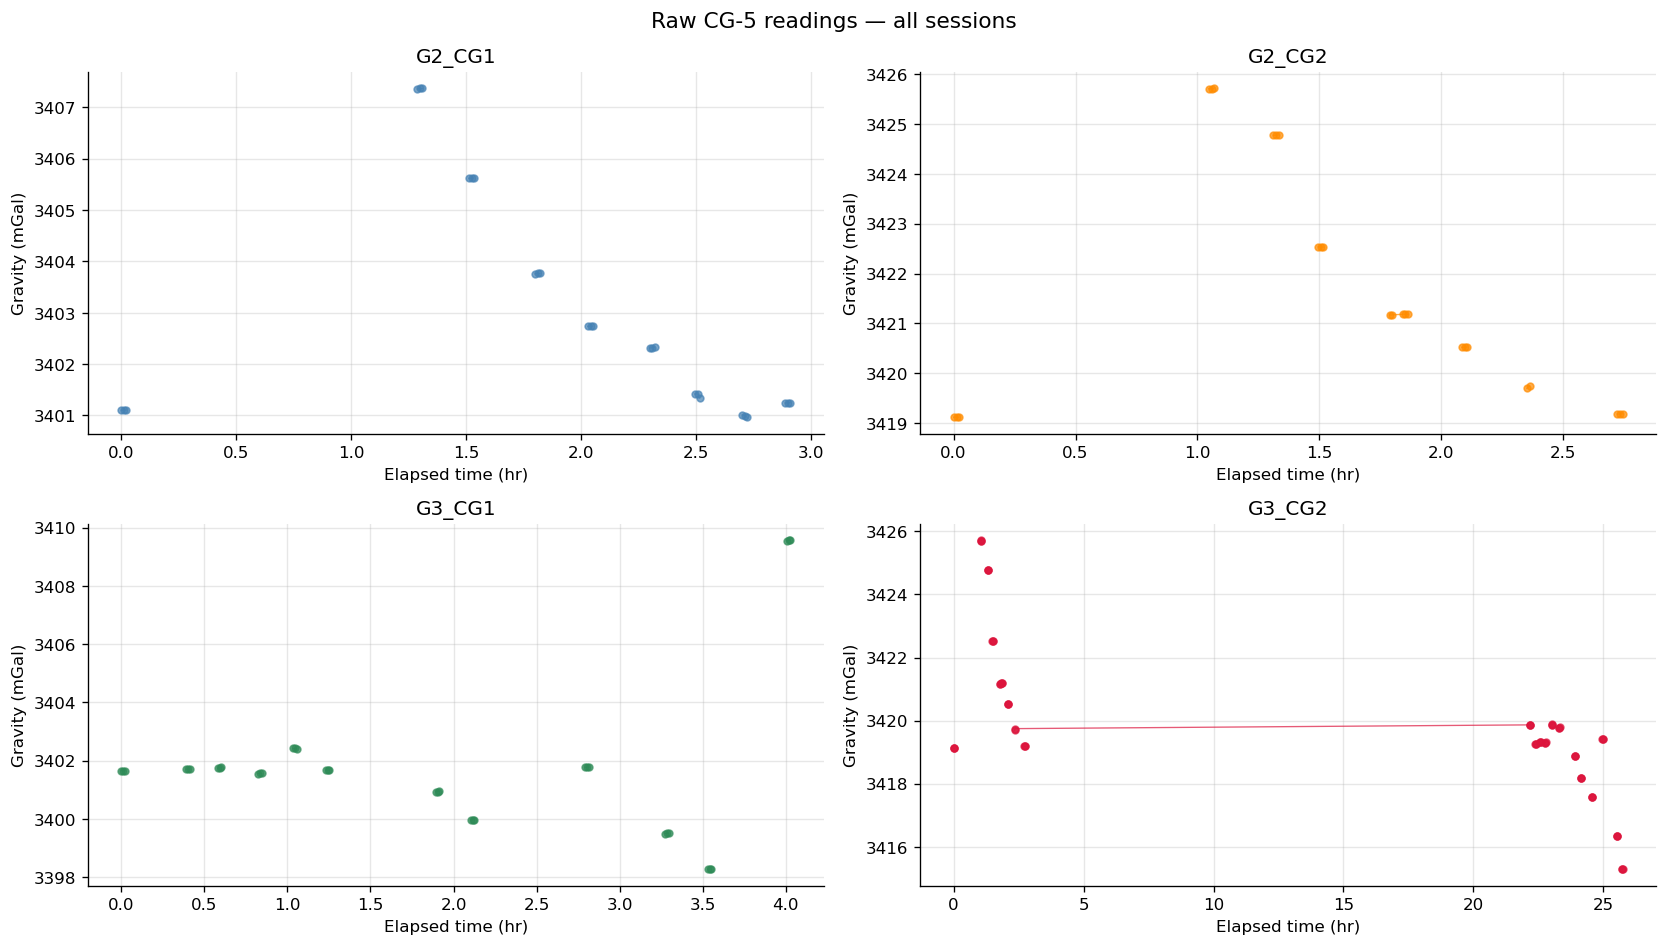

In [45]:
## Figure 1: 
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
palette = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for ax, (key, df), color in zip(axes.flatten(), raw.items(), palette):
    for sta, grp in df.groupby('STATION'):
        ax.plot(grp['ELAPSED_HR'], grp['GRAV'], 'o-', ms=4, lw=0.8, color=color, alpha=0.7)
    ax.set_title(key)
    ax.set_xlabel('Elapsed time (hr)')
    ax.set_ylabel('Gravity (mGal)')

fig.suptitle('Raw CG-5 readings — all sessions', fontsize=13)
plt.tight_layout()
plt.show()

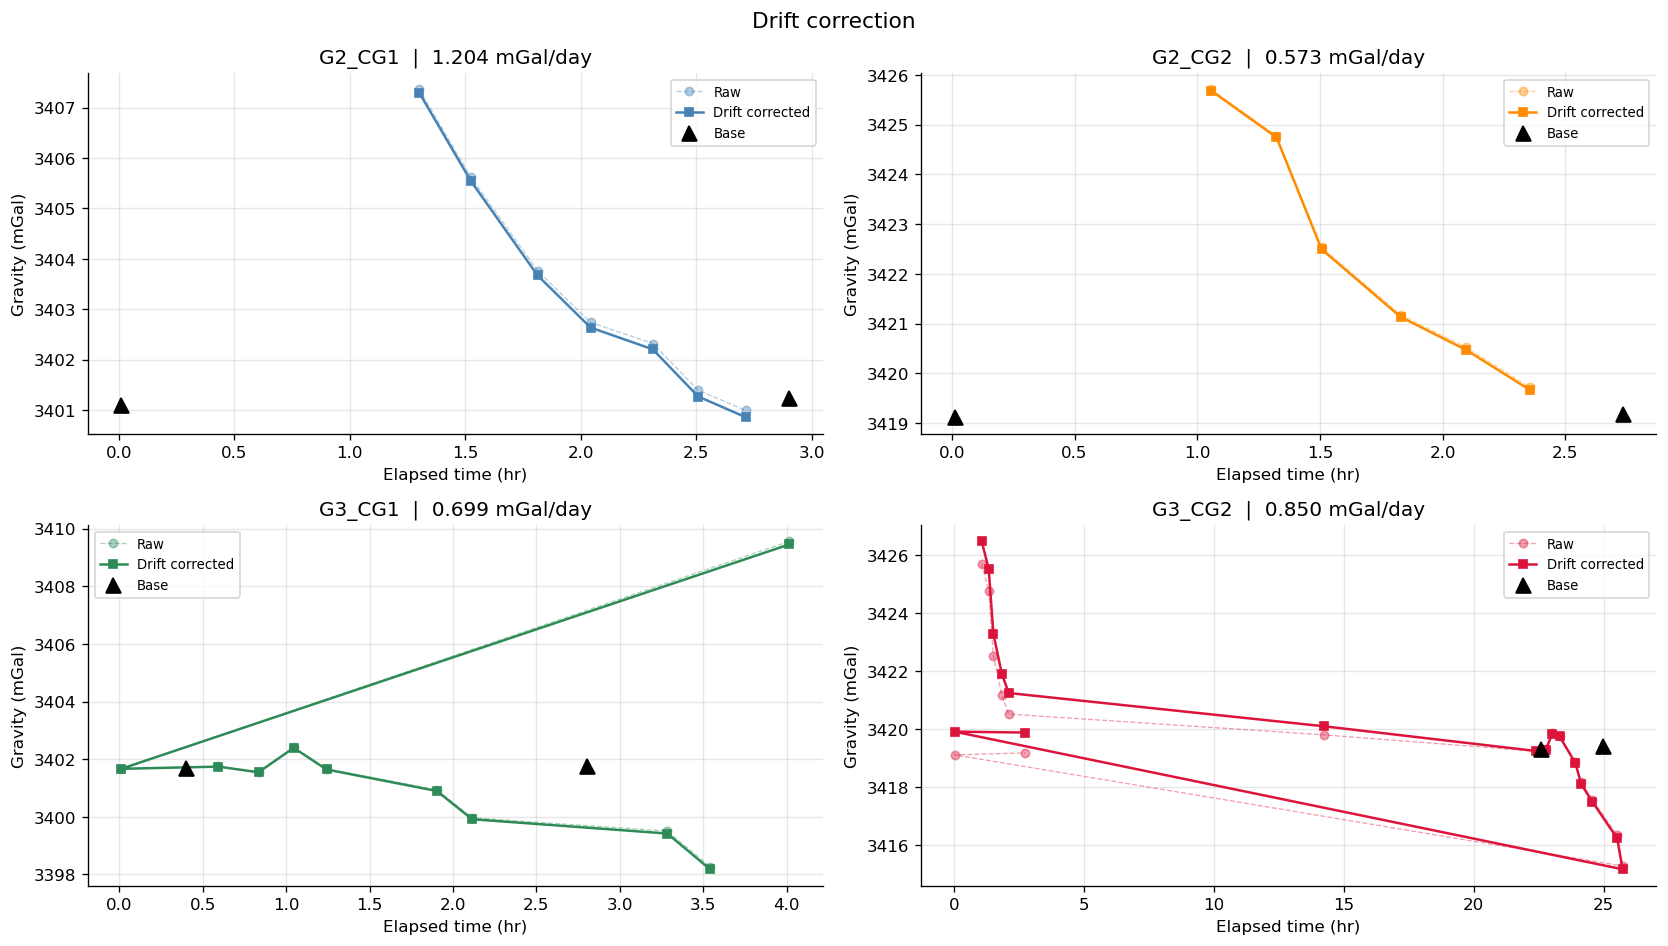

In [46]:
## Figure 2: 
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
palette = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for ax, (key, df), color in zip(axes.flatten(), corrected.items(), palette):
    bs, be = BASE_IDS[key]
    field = df[~df['STATION'].isin([bs, be])]
    base  = df[df['STATION'].isin([bs, be])]
    ax.plot(field['ELAPSED_HR'], field['GRAV'], 'o--', ms=5, lw=0.8,
            color=color, alpha=0.4, label='Raw')
    ax.plot(field['ELAPSED_HR'], field['GRAV_DC'], 's-', ms=5, lw=1.5,
            color=color, label='Drift corrected')
    ax.plot(base['ELAPSED_HR'], base['GRAV'], 'k^', ms=9, zorder=5, label='Base')
    ax.set_title(f'{key}  |  {drift_rates[key]*24:.3f} mGal/day')
    ax.set_xlabel('Elapsed time (hr)')
    ax.set_ylabel('Gravity (mGal)')
    ax.legend(fontsize=8)

fig.suptitle('Drift correction', fontsize=13)
plt.tight_layout()
plt.show()

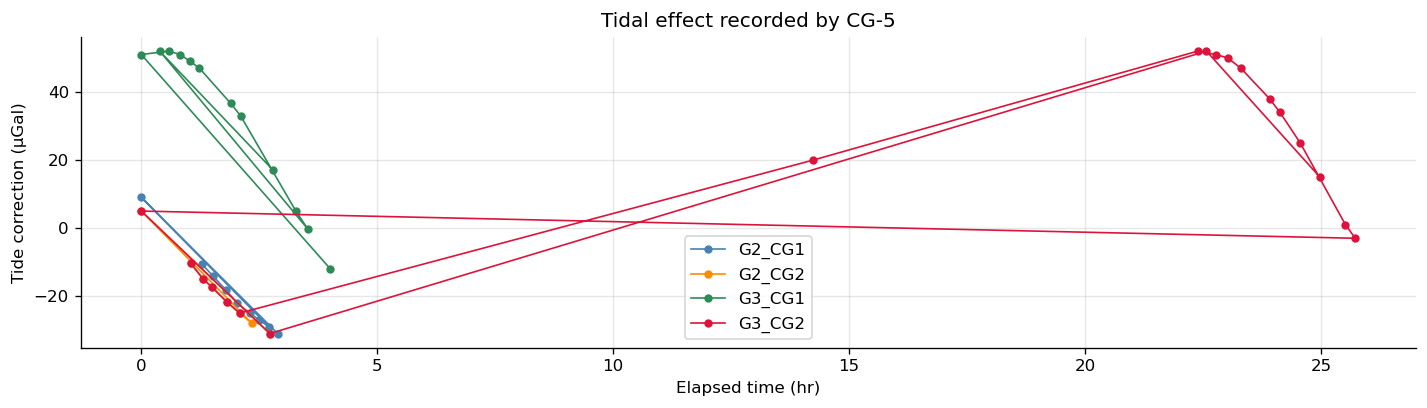

In [47]:
## Tidal Effect
fig, ax = plt.subplots(figsize=(12, 3.5))
palette = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for (key, df), color in zip(corrected.items(), palette):
    ax.plot(df['ELAPSED_HR'], df['TIDE'] * 1000, 'o-', ms=4, lw=1, color=color, label=key)

ax.set_xlabel('Elapsed time (hr)')
ax.set_ylabel('Tide correction (μGal)')
ax.set_title('Tidal effect recorded by CG-5')
ax.legend()
plt.tight_layout()
plt.show()

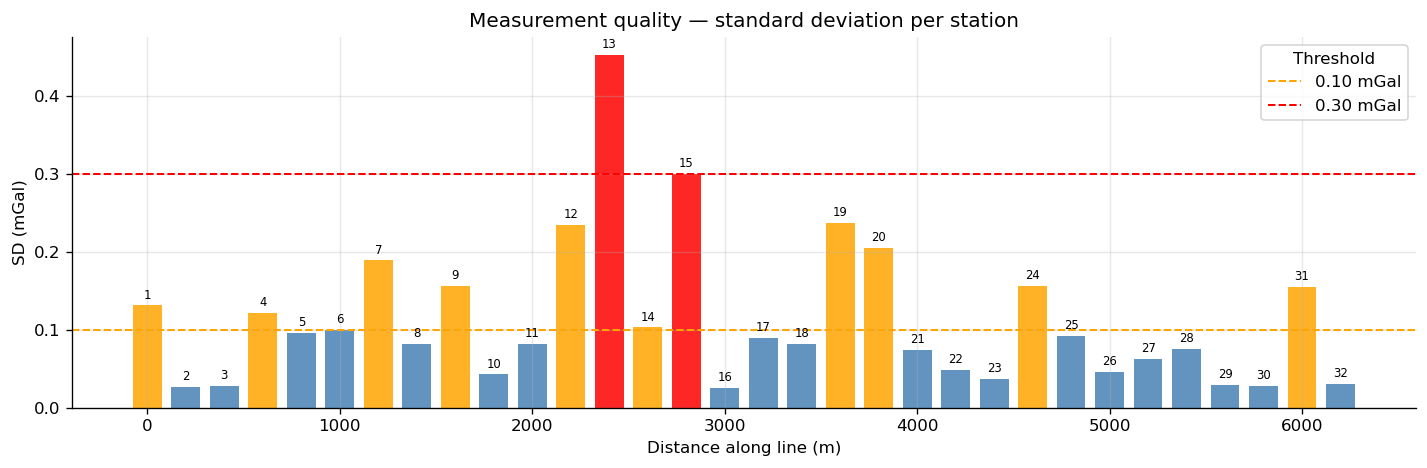

Flagged stations (SD > 0.1):
 STATION  DIST_M    SD
     1.0     0.0 0.131
     4.0   600.0 0.122
     7.0  1200.0 0.189
     9.0  1600.0 0.156
    12.0  2200.0 0.234
    13.0  2400.0 0.453
    14.0  2600.0 0.103
    15.0  2800.0 0.301
    19.0  3600.0 0.237
    20.0  3800.0 0.205
    24.0  4600.0 0.156
    31.0  6000.0 0.155


In [48]:
bar_colors = ['steelblue' if s <= 0.1 else 'orange' if s <= 0.3 else 'red'
              for s in combined['SD']]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(combined['DIST_M'], combined['SD'], color=bar_colors, width=150, alpha=0.85)
ax.axhline(0.1, color='orange', lw=1.2, ls='--', label='0.10 mGal')
ax.axhline(0.3, color='red',    lw=1.2, ls='--', label='0.30 mGal')

for _, row in combined.iterrows():
    ax.text(row['DIST_M'], row['SD'] + 0.005, f"{int(row['STATION'])}",
            ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Distance along line (m)')
ax.set_ylabel('SD (mGal)')
ax.set_title('Measurement quality — standard deviation per station')
ax.legend(title='Threshold')
plt.tight_layout()
plt.show()

flagged = combined[combined['SD'] > 0.1]
if len(flagged):
    print(f'Flagged stations (SD > 0.1):')
    print(flagged[['STATION','DIST_M','SD']].round(3).to_string(index=False))

In [70]:
import folium
import branca.colormap as cm
import numpy as np

BASE_LAT = 40.426279
BASE_LON = -106.825162
BEARING_DEG = 180  # due south along Hwy 131

combined['LAT'] = BASE_LAT - (combined['DIST_M'] / 111320)
combined['LON'] = BASE_LON

base_lat = BASE_LAT
base_lon = BASE_LON


sba_min, sba_max = combined['SBA'].min(), combined['SBA'].max()
colormap = cm.LinearColormap(
    colors=['#2166ac','#92c5de','#f7f7f7','#f4a582','#d6604d'],
    vmin=sba_min, vmax=sba_max,
    caption='Simple Bouguer Anomaly (mGal)'
)

m = folium.Map(location=[base_lat, base_lon], zoom_start=14)

folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri', name='Satellite'
).add_to(m)

folium.PolyLine(list(zip(lats, lons)), color='white', weight=1.5, opacity=0.6).add_to(m)

folium.Marker(
    location=[base_lat, base_lon],
    popup='Base station',
    icon=folium.Icon(color='black', icon='star')
).add_to(m)

for _, row in combined.iterrows():
    folium.CircleMarker(
        location=[row['LAT'], row['LON']],
        radius=5,
        color='white', weight=0.5,
        fill=True, fill_color=colormap(row['SBA']), fill_opacity=0.9,
        popup=folium.Popup(
            f"<b>Station {int(row['STATION'])}</b><br>"
            f"Dist: {row['DIST_M']:.0f} m<br>"
            f"SBA: {row['SBA']:.3f} mGal",
            max_width=150
        ),
        tooltip=f"Sta {int(row['STATION'])} SBA={row['SBA']:.2f}"
    ).add_to(m)

colormap.add_to(m)
folium.LayerControl().add_to(m)
m.save('gravity_map.html')
from IPython.display import IFrame
IFrame('gravity_map.html', width='100%', height=500)

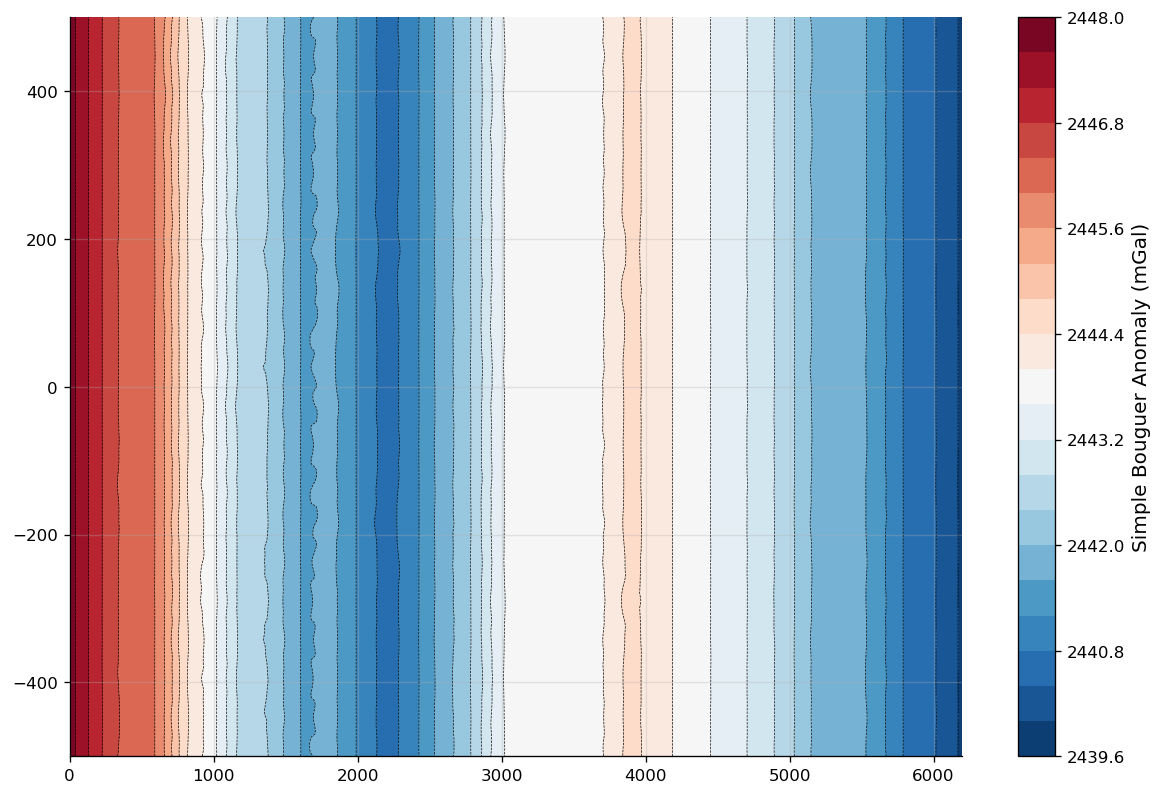

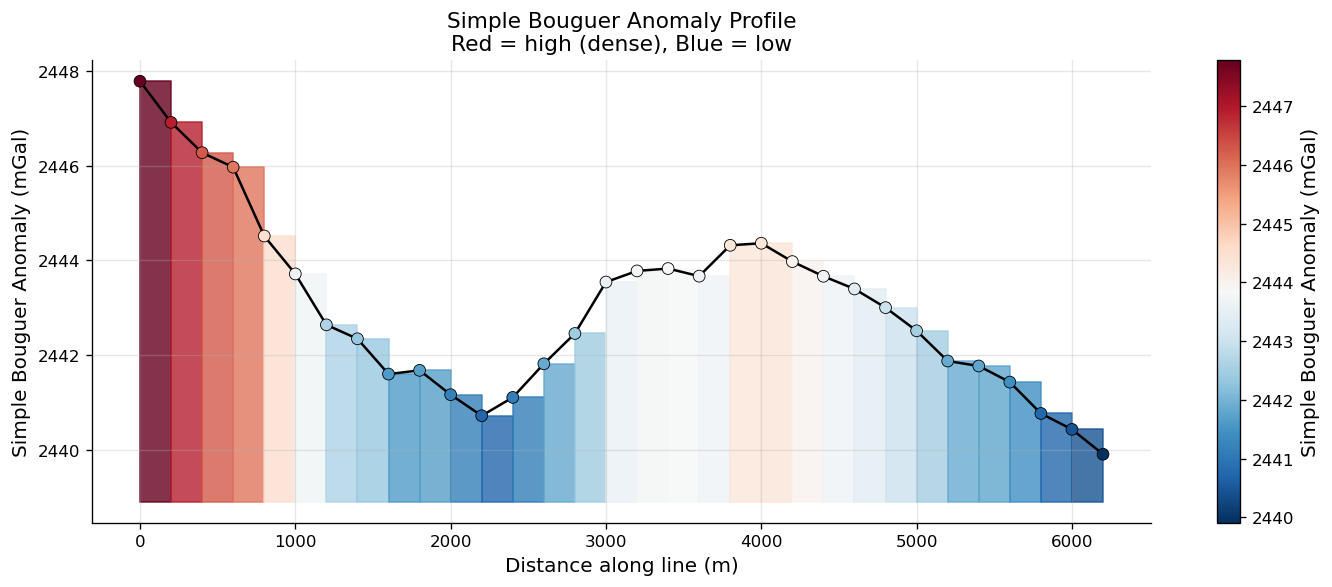

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Create a 2D grid by extending the line perpendicular
# Width of extrapolation either side of line (metres)
HALF_WIDTH = 500

x = combined['DIST_M'].values
z = combined['SBA'].values


fig, ax = plt.subplots(figsize=(12, 8))

cf = ax.contourf(grid_x, grid_y, grid_z, levels=20,
                 cmap='RdBu_r')
cs = ax.contour(grid_x, grid_y, grid_z, levels=20,
                colors='k', linewidths=0.4, linestyles='--')

cbar = plt.colorbar(cf, ax=ax)
cbar.set_label('Simple Bouguer Anomaly (mGal)', fontsize=12)

fig, ax = plt.subplots(figsize=(12, 5))

x = combined['DIST_M'].values
z = combined['SBA'].values

# Filled area under curve coloured by value
for i in range(len(x)-1):
    ax.fill_betweenx([z.min()-1, z[i]], x[i], x[i+1],
                     color=plt.cm.RdBu_r((z[i]-z.min())/(z.max()-z.min())),
                     alpha=0.8)

ax.plot(x, z, 'k-', lw=1.5)
ax.scatter(x, z, c=z, cmap='RdBu_r', s=50, zorder=5, edgecolors='k', linewidths=0.5)

sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(z.min(), z.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Simple Bouguer Anomaly (mGal)', fontsize=12)

ax.set_xlabel('Distance along line (m)', fontsize=12)
ax.set_ylabel('Simple Bouguer Anomaly (mGal)', fontsize=12)
ax.set_title('Simple Bouguer Anomaly Profile\nRed = high (dense), Blue = low', fontsize=13)
plt.tight_layout()
plt.show()